In [ ]:
!pip install -q transformers mergekit datasets peft accelerate bitsandbytes trl huggingface_hub rouge-score nltk

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.7/431.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 115.2 MB/s eta 0:00:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
from huggingface_hub import login
import copy
import torch
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from datasets import load_dataset
from google.colab import userdata

In [ ]:
HF_TOKEN = userdata.get('HF_API_KEY')
login(HF_TOKEN)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

nltk.download("wordnet")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
HF_USERNAME = "sohammandal01"
BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

SFT_LOCAL_DIR = "./model_sft_lora"
DARE_LOCAL_DIR_TEMPLATE = "./model_sft_dare_{p}"

SFT_REPO_ID = f"{HF_USERNAME}/model_sft_lora"
DARE_REPO_IDS = {
    0.1: f"{HF_USERNAME}/model_sft_dare_0.1",
    0.3: f"{HF_USERNAME}/model_sft_dare_0.3",
    0.5: f"{HF_USERNAME}/model_sft_dare_0.5",
    0.7: f"{HF_USERNAME}/model_sft_dare_0.7",
}

MAX_SEQ_LENGTH = 512
DARE_DROP_RATES = [0.1, 0.3, 0.5, 0.7]
print("Base model:", BASE_MODEL_NAME)
print("SFT repo:", SFT_REPO_ID)
print("DARE repos:", DARE_REPO_IDS)

Base model: Qwen/Qwen2.5-1.5B-Instruct
SFT repo: sohammandal01/model_sft_lora
DARE repos: {0.1: 'sohammandal01/model_sft_dare_0.1', 0.3: 'sohammandal01/model_sft_dare_0.3', 0.5: 'sohammandal01/model_sft_dare_0.5', 0.7: 'sohammandal01/model_sft_dare_0.7'}


In [ ]:
dataset = load_dataset("medalpaca/medical_meadow_medqa",token=HF_TOKEN)
data = dataset["train"]

train_size = int(0.6 * len(data))
val_size = int(0.2 * len(data))

train_data = data.select(range(train_size))
val_data = data.select(range(train_size, train_size + val_size))
test_data = data.select(range(train_size + val_size, len(data)))

README.md: 0.00B [00:00, ?B/s]

medical_meadow_medqa.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

In [ ]:
train_data.select(range(5))

Dataset({
    features: ['input', 'instruction', 'output'],
    num_rows: 5
})

In [ ]:
def format_prompt(example):
    prompt_text = f"""### Instruction:
{example['instruction']}

### Input:
{example.get('input', '')}

### Response:
"""
    response_text = example['output']

    return {
        "prompt": prompt_text,
        "response": response_text
    }

train_data = train_data.map(format_prompt, remove_columns=["instruction", "input", "output"])
val_data = val_data.map(format_prompt, remove_columns=["instruction", "input", "output"])
test_data = test_data.map(format_prompt, remove_columns=["instruction", "input", "output"])

Map:   0%|          | 0/6106 [00:00<?, ? examples/s]

Map:   0%|          | 0/2035 [00:00<?, ? examples/s]

Map:   0%|          | 0/2037 [00:00<?, ? examples/s]

In [ ]:
train_data[0]

{'prompt': "### Instruction:\nPlease answer with one of the option in the bracket\n\n### Input:\nQ:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?? \n{'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Ciprofloxacin', 'D': 'Doxycycline', 'E': 'Nitrofurantoin'},\n\n### Response:\n",
 'response': 'E: Nitrofurantoin'}

In [ ]:
model_name = BASE_MODEL_NAME
model = AutoModelForCausalLM.from_pretrained(model_name,token=HF_TOKEN,device_map="auto",torch_dtype=torch.bfloat16,trust_remote_code=True).to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN,trust_remote_code=True)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
tokenizer.padding_side = "right"
max_seq_length = MAX_SEQ_LENGTH

def tokenize_function(example):
    full_text = example["prompt"] + example["response"]

    tokenized_full_text = tokenizer(
        full_text,
        max_length=max_seq_length,
        truncation=True,
        add_special_tokens=True,
        return_overflowing_tokens=False,
    )

    tokenized_prompt_only = tokenizer(
        example["prompt"],
        max_length=max_seq_length,
        truncation=True,
        add_special_tokens=True,
        return_overflowing_tokens=False,
    )
    prompt_len = len(tokenized_prompt_only["input_ids"])
    labels = list(tokenized_full_text["input_ids"])

    for i in range(prompt_len):
        labels[i] = -100

    input_ids = tokenized_full_text["input_ids"]
    attention_mask = tokenized_full_text["attention_mask"]

    padding_length = max_seq_length - len(input_ids)

    if tokenizer.padding_side == "right":
        input_ids = input_ids + [tokenizer.pad_token_id] * padding_length
        attention_mask = attention_mask + [0] * padding_length
        labels = labels + [-100] * padding_length
    else:
        input_ids = [tokenizer.pad_token_id] * padding_length + input_ids
        attention_mask = [0] * padding_length + attention_mask
        labels = [-100] * padding_length + labels

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


train_data_tokenized = train_data.map(tokenize_function, remove_columns=["prompt", "response"])
val_data_tokenized = val_data.map(tokenize_function, remove_columns=["prompt", "response"])
test_data_tokenized = test_data.map(tokenize_function, remove_columns=["prompt", "response"])

Map:   0%|          | 0/6106 [00:00<?, ? examples/s]

Map:   0%|          | 0/2035 [00:00<?, ? examples/s]

Map:   0%|          | 0/2037 [00:00<?, ? examples/s]

In [ ]:
training_args = TrainingArguments(
    output_dir=SFT_LOCAL_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    remove_unused_columns=False
)

In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(model=model, args=training_args, train_dataset=train_data_tokenized, eval_dataset=val_data_tokenized, data_collator=data_collator)
trainer.train()

Step,Training Loss,Validation Loss
200,1.640909,1.603678
400,1.463579,1.478651
600,1.423916,1.385562
800,1.032602,1.380644
1000,0.871134,1.348610
1200,0.836033,1.338023
1400,0.827541,1.336592


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=1528, training_loss=1.1916465022801104, metrics={'train_runtime': 991.5416, 'train_samples_per_second': 12.316, 'train_steps_per_second': 1.541, 'total_flos': 4.915777383904051e+16, 'train_loss': 1.1916465022801104, 'epoch': 2.0})

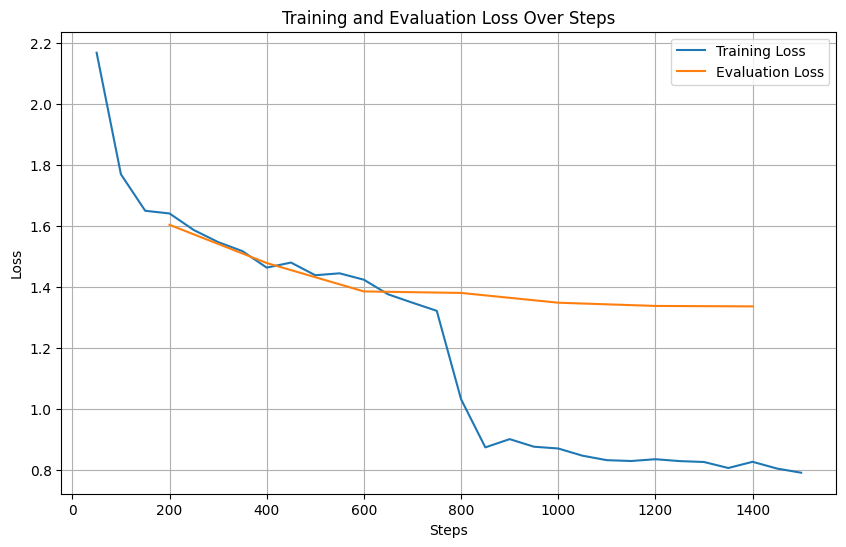

In [ ]:
training_losses = []
eval_losses = []
steps = []

for log in trainer.state.log_history:
    if 'loss' in log:
        training_losses.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log:
        eval_losses.append(log['eval_loss'])

plt.figure(figsize=(10, 6))
plt.plot(steps[:len(training_losses)], training_losses, label='Training Loss')

eval_steps = [log['step'] for log in trainer.state.log_history if 'eval_loss' in log]
plt.plot(eval_steps, eval_losses, label='Evaluation Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss Over Steps')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(model_name,token=HF_TOKEN,device_map="auto",torch_dtype=torch.bfloat16)
sft_model = AutoModelForCausalLM.from_pretrained("./model_sft_lora/checkpoint-1528", token=HF_TOKEN, device_map="auto", torch_dtype=torch.bfloat16)

merged_model = sft_model

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [ ]:
def build_dare_model(base_model, sft_model, drop_rate=0.5, scale=1.0):
    dare_model = copy.deepcopy(base_model)

    for (name, base_param), (_, sft_param) in zip(
        base_model.named_parameters(),
        sft_model.named_parameters()
    ):
        delta = sft_param.data - base_param.data
        mask = torch.bernoulli(
            torch.full_like(delta, drop_rate)
        )

        delta_dropped = delta * (1 - mask)
        delta_rescaled = delta_dropped / (1 - drop_rate)
        delta_final = scale * delta_rescaled

        dare_model.state_dict()[name].add_(delta_final)

    return dare_model

In [ ]:
dare_models = {}

for p in DARE_DROP_RATES:
    print(f"Processing drop rate: {p}")

    dare_model = build_dare_model(base_model, sft_model, drop_rate=p, scale=1.0)
    dare_models[p] = dare_model
    dare_model.save_pretrained(DARE_LOCAL_DIR_TEMPLATE.format(p=p))

Processing drop rate: 0.1


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing drop rate: 0.3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing drop rate: 0.5


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing drop rate: 0.7


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def evaluate_metrics(model, dataset, tokenizer, num_samples=50):
    bleu_scores = []
    rouge_scores = []
    meteor_scores = []

    smooth = SmoothingFunction().method1
    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    for example in dataset.select(range(num_samples)):
        prompt = example['prompt']

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=150)

        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
        if prompt in pred:
            start_index = pred.find(prompt) + len(prompt)
            pred = pred[start_index:].strip()

        ref = example["response"]

        bleu = sentence_bleu(
            [ref.split()],
            pred.split(),
            smoothing_function=smooth
        )
        bleu_scores.append(bleu)

        rouge_l = rouge.score(ref, pred)['rougeL'].fmeasure
        rouge_scores.append(rouge_l)

        meteor = meteor_score([ref.split()], pred.split())
        meteor_scores.append(meteor)

    return {
        "BLEU": np.mean(bleu_scores),
        "ROUGE-L": np.mean(rouge_scores),
        "METEOR": np.mean(meteor_scores)
    }

In [ ]:
sft_results = evaluate_metrics(sft_model, test_data, tokenizer)
print("SFT:", sft_results)

SFT: {'BLEU': np.float64(0.010656834021080905), 'ROUGE-L': np.float64(0.06685049557185177), 'METEOR': np.float64(0.11820284677236226)}


In [ ]:
dare_results = {}

for p, model in dare_models.items():
    print(f"Evaluating DARE p={p}")
    dare_results[p] = evaluate_metrics(model, test_data, tokenizer)

print(dare_results)

Evaluating DARE p=0.1
Evaluating DARE p=0.3
Evaluating DARE p=0.5
Evaluating DARE p=0.7
{0.1: {'BLEU': np.float64(0.010829488746595235), 'ROUGE-L': np.float64(0.06292079475940861), 'METEOR': np.float64(0.10635241642198384)}, 0.3: {'BLEU': np.float64(0.01019469729064678), 'ROUGE-L': np.float64(0.057842321438336154), 'METEOR': np.float64(0.09854252988170241)}, 0.5: {'BLEU': np.float64(0.013953168723867532), 'ROUGE-L': np.float64(0.07914225320041847), 'METEOR': np.float64(0.12291858091794548)}, 0.7: {'BLEU': np.float64(0.03355861845609381), 'ROUGE-L': np.float64(0.08696587885119993), 'METEOR': np.float64(0.12895443701417786)}}


In [ ]:
print("\n===== FINAL RESULTS =====\n")

print("SFT Model:")
print(sft_results)

for p, res in dare_results.items():
    print(f"\nDARE (p={p}):")
    print(res)


===== FINAL RESULTS =====

SFT Model:
{'BLEU': np.float64(0.010656834021080905), 'ROUGE-L': np.float64(0.06685049557185177), 'METEOR': np.float64(0.11820284677236226)}

DARE (p=0.1):
{'BLEU': np.float64(0.010829488746595235), 'ROUGE-L': np.float64(0.06292079475940861), 'METEOR': np.float64(0.10635241642198384)}

DARE (p=0.3):
{'BLEU': np.float64(0.01019469729064678), 'ROUGE-L': np.float64(0.057842321438336154), 'METEOR': np.float64(0.09854252988170241)}

DARE (p=0.5):
{'BLEU': np.float64(0.013953168723867532), 'ROUGE-L': np.float64(0.07914225320041847), 'METEOR': np.float64(0.12291858091794548)}

DARE (p=0.7):
{'BLEU': np.float64(0.03355861845609381), 'ROUGE-L': np.float64(0.08696587885119993), 'METEOR': np.float64(0.12895443701417786)}


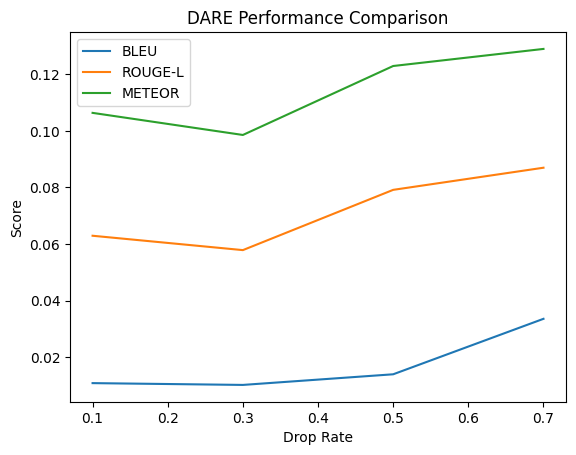

In [ ]:
drop_rates = list(dare_results.keys())

bleu = [dare_results[p]["BLEU"] for p in drop_rates]
rouge = [dare_results[p]["ROUGE-L"] for p in drop_rates]
meteor = [dare_results[p]["METEOR"] for p in drop_rates]

plt.plot(drop_rates, bleu, label="BLEU")
plt.plot(drop_rates, rouge, label="ROUGE-L")
plt.plot(drop_rates, meteor, label="METEOR")

plt.xlabel("Drop Rate")
plt.ylabel("Score")
plt.title("DARE Performance Comparison")
plt.legend()
plt.show()

In [ ]:
print(f"Pushing models to Hugging Face Hub under username: {HF_USERNAME}")

sft_model.push_to_hub(
    repo_id=SFT_REPO_ID,
    commit_message="Upload standardized SFT LoRA model for Medical Meadow MedQA"
)
tokenizer.push_to_hub(repo_id=SFT_REPO_ID)
print(f"Uploaded: {SFT_REPO_ID}")

for p, model in dare_models.items():
    repo_id = DARE_REPO_IDS[p]
    model.push_to_hub(
        repo_id=repo_id,
        commit_message=f"Upload standardized DARE model with drop rate {p}"
    )
    tokenizer.push_to_hub(repo_id=repo_id)
    print(f"Uploaded: {repo_id}")

print("All Part 1 models uploaded successfully.")

Pushing models to Hugging Face Hub under username: sohammandal01


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...dg0csk1/model.safetensors:   0%|          |  602kB / 3.09GB            

...

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpopd8ictw/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Uploaded: sohammandal01/model_sft_dare_0.7
All Part 1 models uploaded successfully.
